# Investigation

In [69]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt


from sqlalchemy import create_engine, text

## Load Data

In [70]:
load_dotenv('../.env')

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [71]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print(result.fetchone())

(1,)


In [73]:
users             = pd.read_sql("SELECT * FROM users", engine)
app_events        = pd.read_sql("SELECT * FROM app_events", engine)
loan_applications = pd.read_sql("SELECT * FROM loan_applications", engine)
installments      = pd.read_sql("SELECT * FROM installments", engine)
repayments        = pd.read_sql("SELECT * FROM repayments", engine)
dim_date          = pd.read_sql("SELECT * FROM dim_date", engine)

# Normalize `status`

In [98]:
loan_applications['status'] = loan_applications['status'].str.upper()
loan_applications['status'].value_counts()

status
APPROVED    4839
REJECTED    3043
PENDING      234
Name: count, dtype: int64

# Convert Jalali due to Gregorian

In [105]:
date_map = dim_date.set_index('date_jalali')['date_gregorian']
installments['due_date_gregorian'] = pd.to_datetime(installments['due_date'].map(date_map))

unmapped = installments[installments['due_date_gregorian'].isna()]
print(f"{len(unmapped)} unmapped out of {len(installments)}")
print(unmapped['due_date'].value_counts().sort_index().head())

1596 unmapped out of 31494
due_date
1406/01/01    29
1406/01/02    29
1406/01/03    22
1406/01/04    24
1406/01/05    21
Name: count, dtype: int64


In [106]:
paid_per_installment = repayments.groupby('installment_id')['amount'].sum().rename('amount_paid')
last_paid_at = repayments.groupby('installment_id')['paid_at'].max().rename('last_paid_at')

inst = installments.merge(paid_per_installment, left_on='installment_id', right_index=True, how='left')
inst = inst.merge(last_paid_at, left_on='installment_id', right_index=True, how='left')

# installments with zero repayments won't have a match above -> NaN -> should be treated as 0 paid
inst['amount_paid'] = inst['amount_paid'].fillna(0)
inst['fully_paid'] = inst['amount_paid'] >= inst['amount']

In [107]:
paid = inst[inst['fully_paid']].copy()
paid['lag_days'] = (paid['last_paid_at'] - paid['due_date_gregorian']).dt.days

print(paid['lag_days'].describe())
print("paid within 7 days:", (paid['lag_days'] <= 7).mean().round(3))
print("paid within 30 days:", (paid['lag_days'] <= 30).mean().round(3))

count    12415.000000
mean       -18.567861
std         58.316321
min       -359.000000
25%         -5.000000
50%         -2.000000
75%          1.000000
max         55.000000
Name: lag_days, dtype: float64
paid within 7 days: 0.969
paid within 30 days: 0.982


In [108]:
dim_date['date_gregorian'] = pd.to_datetime(dim_date['date_gregorian'])
jalali_lookup = dim_date.set_index('date_gregorian')[['jalali_year','jalali_month','jalali_month_name']]
inst = inst.merge(jalali_lookup, left_on='due_date_gregorian', right_index=True, how='left')

SNAPSHOT = pd.Timestamp('2026-07-15')
GRACE_DAYS = 30

inst['had_grace_period'] = inst['due_date_gregorian'] < (SNAPSHOT - pd.Timedelta(days=GRACE_DAYS))
inst['defaulted'] = inst['had_grace_period'] & (~inst['fully_paid'])

In [110]:
mature = inst[inst['had_grace_period']].copy()

monthly = mature.groupby(['jalali_year','jalali_month','jalali_month_name']).agg(
    n_installments=('installment_id','count'),
    n_defaulted=('defaulted','sum')
).reset_index()
monthly['default_rate'] = (monthly['n_defaulted'] / monthly['n_installments']).round(4)
monthly

,jalali_year,jalali_month,jalali_month_name,n_installments,n_defaulted,default_rate
0,1404.0,8.0,آبان,134,3,0.0224
1,1404.0,9.0,آذر,383,13,0.0339
2,1404.0,10.0,دی,660,30,0.0455
3,1404.0,11.0,بهمن,937,50,0.0534
4,1404.0,12.0,اسفند,1191,65,0.0546
5,1405.0,1.0,فروردین,1549,92,0.0594
6,1405.0,2.0,اردیبهشت,2272,215,0.0946
7,1405.0,3.0,خرداد,2462,354,0.1438


In [111]:
from statsmodels.stats.proportion import proportions_ztest

farvardin = monthly[monthly['jalali_month']==1].iloc[0]
ordibehesht = monthly[monthly['jalali_month']==2].iloc[0]

stat, pval = proportions_ztest(
    [farvardin['n_defaulted'], ordibehesht['n_defaulted']],
    [farvardin['n_installments'], ordibehesht['n_installments']]
)
print(f"z-stat: {stat:.3f}, p-value: {pval:.2e}")

z-stat: -3.934, p-value: 8.35e-05


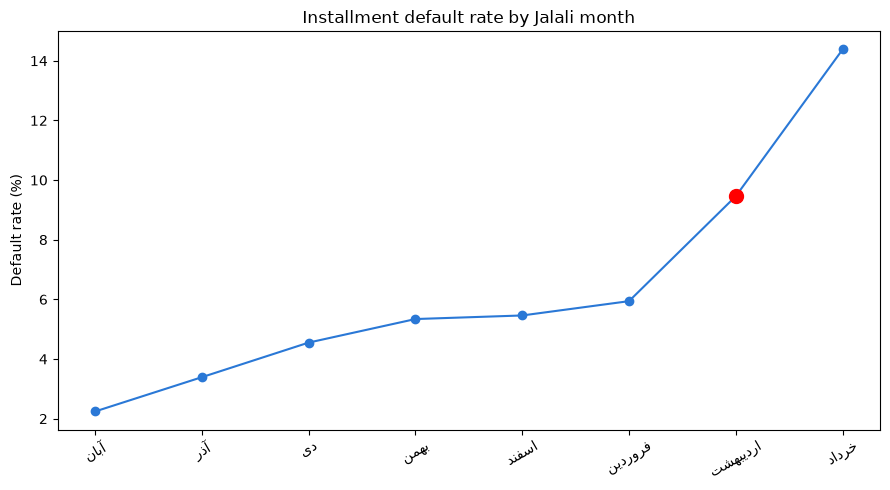

In [112]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(monthly['jalali_month_name'], monthly['default_rate']*100, marker='o', color='#2a78d6')
# highlight Ordibehesht
ord_idx = monthly.index[monthly['jalali_month']==2][0]
ax.scatter(monthly['jalali_month_name'][ord_idx], monthly['default_rate'][ord_idx]*100, color='red', zorder=5, s=100)
ax.set_ylabel('Default rate (%)')
ax.set_title('Installment default rate by Jalali month')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Another Solution

In [146]:
users             = pd.read_sql("SELECT * FROM users", engine)
app_events        = pd.read_sql("SELECT * FROM app_events", engine)
loan_applications = pd.read_sql("SELECT * FROM loan_applications", engine)
installments      = pd.read_sql("SELECT * FROM installments", engine)
repayments        = pd.read_sql("SELECT * FROM repayments", engine)
dim_date          = pd.read_sql("SELECT * FROM dim_date", engine)

In [147]:
# Convert Jalali due_date using dim_date
installments = installments.merge(
    dim_date[["date_jalali", "date_gregorian", "jalali_year", "jalali_month", "jalali_month_name"]],
    left_on="due_date",
    right_on="date_jalali",
    how="left"
)

# Convert dates
installments["date_gregorian"] = pd.to_datetime(installments["date_gregorian"])
repayments["paid_at"] = pd.to_datetime(repayments["paid_at"])

In [165]:
installments_with_payment = installments.merge(
    repayments[['installment_id', 'paid_at', 'amount']], 
    on='installment_id', 
    how='left',
    suffixes=('_installment', '_paid')
)

In [166]:
installments_with_payment['is_paid'] = ~installments_with_payment['paid_at'].isna()

In [168]:
installments_with_payment['payment_delay_days'] = (
    installments_with_payment['paid_at'] - installments_with_payment['date_gregorian']
).dt.days

In [171]:
installments_with_payment[['installment_id', 'due_date', 'date_gregorian', 'paid_at', 'is_paid', 'payment_delay_days']].head(10)

,installment_id,due_date,date_gregorian,paid_at,is_paid,payment_delay_days
0,1,1405/02/30,2026-05-20,NaT,False,NaN
1,2,1405/03/29,2026-06-19,NaT,False,NaN
2,3,1405/04/28,2026-07-19,NaT,False,NaN
3,4,1405/03/19,2026-06-09,2026-06-04 21:19:06,True,-5.0
4,5,1405/04/18,2026-07-09,2026-07-05 04:32:24,True,-4.0
5,6,1405/05/17,2026-08-08,NaT,False,NaN
6,7,1405/06/16,2026-09-07,NaT,False,NaN
7,8,1405/07/15,2026-10-07,NaT,False,NaN
8,9,1405/08/15,2026-11-06,NaT,False,NaN
9,10,1405/09/15,2026-12-06,NaT,False,NaN


In [193]:
print("📋 نمونه دیتای اقساط با وضعیت پرداخت:")
print(f"\nتعداد کل اقساط: {len(installments_with_payment):,}")
print(f"تعداد اقساط پرداخت شده: {installments_with_payment['is_paid'].sum():,}")
print(f"تعداد اقساط پرداخت نشده: {(~installments_with_payment['is_paid']).sum():,}")


📋 نمونه دیتای اقساط با وضعیت پرداخت:

تعداد کل اقساط: 31,494
تعداد اقساط پرداخت شده: 12,434
تعداد اقساط پرداخت نشده: 19,060


In [202]:
def calculate_default_rate(df, month_start, month_end):
    """
    محاسبه نرخ نکول برای یک بازه زمانی
    
    Parameters:
    - df: دیتافریم اقساط با ستون‌های date_gregorian و is_paid
    - month_start: اول ماه
    - month_end: آخر ماه
    
    Returns:
    - نرخ نکول (عدد بین 0 تا 1)
    """
    
    # اقساطی که سررسیدشان در این ماه است
    due_this_month = df[
        (df['date_gregorian'] >= month_start) & 
        (df['date_gregorian'] < month_end)
    ]
    
    # if len(due_this_month) == 0:
    #     return np.nan
    month_end = pd.Timestamp('2026-05-23')
    # محاسبه تعداد اقساط نکول شده (پرداخت نشده و بیش از ۳۰ روز تاخیر)
    # برای این کار، فرض می‌کنیم در انتهای ماه وضعیت را چک می‌کنیم
    defaults = due_this_month[
        (~due_this_month['is_paid']) &  # پرداخت نشده
        ((month_end - due_this_month['date_gregorian']).dt.days > 30)  # بیش از ۳۰ روز گذشته
    ]

    try:
        return len(defaults) / len(due_this_month)
    except:
        return 0
        

In [203]:
jalali_date = '1405/02/01'
date_map = dim_date.set_index('date_jalali')['date_gregorian']
test_date = date_map.loc[jalali_date]

test_date = pd.Timestamp(test_date)
rate = calculate_default_rate(
    installments_with_payment, 
    test_date, 
    test_date + pd.DateOffset(months=1)
)
print(f"\n🧪 نرخ نکول برای {test_date.strftime('%Y-%m')}: {rate:.6%}")


🧪 نرخ نکول برای 2026-04: 0.366300%


In [213]:
# ایجاد لیست از همه ماه‌های موجود در دیتا
start_date = pd.Timestamp('2025-03-21')
end_date = pd.Timestamp('2026-05-22')

# تولید تاریخ اول همه ماه‌ها
monthly_dates = pd.date_range(start=start_date, end=end_date, freq='MS')
# print(monthly_dates)
monthly_dates = [
    '1404/01/01',
    '1404/02/01',
    '1404/03/01',
    '1404/04/01',
    '1404/05/01',
    '1404/06/01',
    '1404/07/01',
    '1404/08/01',
    '1404/09/01',
    '1404/10/01',
    '1404/11/01',
    '1404/12/01',
    '1405/01/01',
    '1405/02/01',
    '1405/03/01',
]
test_date = date_map.loc[monthly_dates]
print(test_date.values[0], test_date.values[0]+ pd.DateOffset(months=1))
# لیست برای ذخیره نتایج
monthly_results = []

print("🔄 در حال محاسبه نرخ نکول برای هر ماه...")

for i, month_start in enumerate(test_date.values):
    month_start =  pd.Timestamp(month_start)
    month_end = month_start + pd.DateOffset(months=1)
    
    default_rate = calculate_default_rate(
        installments_with_payment, 
        month_start, 
        month_end
    )
    
    # همچنین تعداد کل اقساط را محاسبه می‌کنیم
    total_installments = len(installments_with_payment[
        (installments_with_payment['date_gregorian'] >= month_start) & 
        (installments_with_payment['date_gregorian'] < month_end)
    ])
    
    monthly_results.append({
        'month_start': monthly_dates[i],
        'month_end': month_end,
        'default_rate': default_rate,
        'total_installments': total_installments
    })

# تبدیل به دیتافریم
df_monthly = pd.DataFrame(monthly_results)

# نمایش نتیجه
print("\n📊 نرخ نکول ماهانه:")
print(df_monthly[['month_start', 'default_rate', 'total_installments']].tail(10))

# ذخیره میانگین متحرک ۳ ماهه
df_monthly['ma_3'] = df_monthly['default_rate'].rolling(3).mean()

print("\n✅ محاسبات کامل شد!")

2025-03-21 2025-04-21 00:00:00
🔄 در حال محاسبه نرخ نکول برای هر ماه...

📊 نرخ نکول ماهانه:
   month_start  default_rate  total_installments
5   1404/06/01      0.000000                   0
6   1404/07/01      0.000000                   0
7   1404/08/01      0.021277                 141
8   1404/09/01      0.033943                 383
9   1404/10/01      0.045521                 681
10  1404/11/01      0.052686                 968
11  1404/12/01      0.054054                1147
12  1405/01/01      0.059393                1549
13  1405/02/01      0.003663                2184
14  1405/03/01      0.000000                3222

✅ محاسبات کامل شد!
